# Review 5. Phase distribution of the clusters

The spectral phase of each cluster of notebook 2, to check that a cluster is not
simply a range of phases.

| input | what it provides |
| --- | --- |
| `results/umap_5100_6450_dim2_nei12_eps0475.csv` | `params.csv` with `umap_x`, `umap_y` and `DB_label` appended, the `n_neighbors = 12` run of notebook 2 |

| output | what it shows |
| --- | --- |
| `figure/review/phase.pdf` / `.png` | the phase histogram of each cluster |


## Imports


In [1]:
import re, csv, os, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Configuration


In [2]:
# Input / output locations
RESULTS_PATH = './results/umap_5100_6450_dim2_nei12_eps0475.csv'

FIGURE_DIR = './figure/review'
OUTPUT_NAME = 'phase'

os.makedirs(FIGURE_DIR, exist_ok=True)

# Cluster labels of the notebook 2 run, as notebook 3 names them
LABEL_COLUMN = 'DB_label'


In [3]:
plt.rcParams['figure.figsize'] = (5.0, 5.0)
plt.rcParams['figure.dpi'] = 300

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
# plt.rcParams['xtick.top'] = 'True'
plt.rcParams["xtick.minor.visible"] = 'True'
plt.rcParams["ytick.minor.visible"] = 'True'

plt.rcParams["xtick.major.width"] = 1
plt.rcParams["ytick.major.width"] = 1
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 7
plt.rcParams["ytick.major.size"] = 7
plt.rcParams["xtick.minor.size"] = 4
plt.rcParams["ytick.minor.size"] = 4

In [4]:
data = pd.read_csv(RESULTS_PATH)


In [5]:
class_91bg = data[data[LABEL_COLUMN] == 4].reset_index(drop=True)
class_91T = data[(data[LABEL_COLUMN] == 3) & (data['SN_type'] == '91T')].reset_index(drop=True)
class_NV1 = data[(data[LABEL_COLUMN] == 3) & (data['SN_type'] == 'NV')].reset_index(drop=True)
class_NV2 = data[data[LABEL_COLUMN] == 5].reset_index(drop=True)
class_HV =  data[data[LABEL_COLUMN] == 1].reset_index(drop=True)
class_Iax =  data[data[LABEL_COLUMN] == 0].reset_index(drop=True)
class_o1 =  data[data[LABEL_COLUMN] == 2].reset_index(drop=True)
class_o2 =  data[data[LABEL_COLUMN] == -1].reset_index(drop=True)


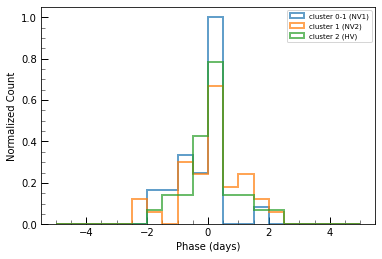

In [6]:
plt.rcParams['figure.figsize'] = (5.0, 5.0)
fig, ax = plt.subplots()

phase_range = (-5, 5)
bins = 20  # bin width = 0.5 days

plt.hist(class_NV1['phase'],  density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 0-1 (NV1)',    color='tab:blue')
# plt.hist(class_91T['phase'],  density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 0-2 (91T)',    color='tab:olive')
plt.hist(class_NV2['phase'],  density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 1 (NV2)',     color='tab:orange')
plt.hist(class_HV['phase'],   density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 2 (HV)',      color='tab:green')
# plt.hist(class_91bg['phase'], density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 3 (91bg)',    color='tab:red')
# plt.hist(class_Iax['phase'],  density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 4 (Iax)',     color='tab:purple')
# plt.hist(class_o1['phase'],   density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 5 (others1)', color='tab:brown')
# plt.hist(class_o2['phase'],   density=True, bins=bins, alpha=0.7, histtype='step', align='mid', range=phase_range, linewidth=2, label='cluster 6 (others2)', color='tab:grey')

ax.set_xlabel(r'Phase (days)')
ax.set_ylabel(r'Normalized Count')

plt.legend(loc='upper right', fontsize=7)

fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.png', bbox_inches='tight', pad_inches=0.05)
plt.show()